# Módulo 3 — Generación del dataset sintético

**Proyecto:** Sistema Inteligente Integrado para RutaViva
**Curso:** Redes Neuronales Artificiales
**Notebook:** `00_generacion_dataset_modulo3.ipynb`

---

## Contexto narrativo: el pivote estratégico de RutaViva

RutaViva, hasta ahora una PME pura de transporte intermunicipal, evalúa un pivote estratégico hacia una oferta de **paquetes turísticos integrales** (transporte + experiencias en destino). El Módulo 3 desarrolla el sistema de recomendación que será el corazón de esta nueva oferta, ayudando a identificar los segmentos de clientes y a personalizar las sugerencias para cada uno.

Este pivote responde directamente a la persona **Andrés** (cliente frecuente) identificada en la fase Empathize del Design Thinking: *"necesito recibir sugerencias de destinos relevantes según mi historial de viajes y mis preferencias"*.

## ¿Por qué un dataset sintético?

El enunciado propone el [Travel Recommendation Dataset](https://www.kaggle.com/datasets/amanmehra23/travel-recommendation-dataset) de Kaggle. Tras una exploración detallada, identificamos limitaciones estructurales que lo hacen inutilizable para un sistema de filtrado colaborativo:

- Solamente **5 destinaciones únicas** (Taj Mahal, Goa Beaches, Jaipur, Kerala, Leh Ladakh) duplicadas 200 veces cada una
- Solamente **3 textos de review** repetidos
- **Mediana de 1 interacción por usuario** (sparsidad 99.75%): imposible aprender embeddings de usuarios
- Ratings uniformemente distribuidos entre 1 y 5 (señal puramente aleatoria)
- Contexto geográfico indio, incompatible con la narrativa RutaViva

Por estas razones, optamos por generar un dataset sintético específicamente diseñado para el caso RutaViva, en coherencia con la decisión metodológica del Módulo 1.

## Diseño del dataset

El dataset modela el comportamiento de **900 viajeros** sobre **30 destinos turísticos** colombianos servidos por las 6 rutas RutaViva, durante el período **2023–2024**.

Cada usuario pertenece a uno de **5 arquetipos** de viajero (negocios, familia, mochilero cultural, pareja, aventurero). Estos arquetipos definen las preferencias del usuario por categoría de destino (urbano, cultural, naturaleza, etc.). **Crucialmente, el modelo de recomendación no recibirá esta información de arquetipo**: deberá descubrirla por sí mismo a partir de las interacciones, lo que constituye uno de los aportes creativos del proyecto (análisis PCA de los embeddings aprendidos).

## Limitaciones reconocidas

Como en el Módulo 1, asumimos plenamente el sesgo de circularidad: el modelo aprenderá patrones que nosotros mismos inyectamos. Para atenuar este sesgo:
- Bruito gaussiano significativo en los ratings
- Diversidad por usuario (ningún usuario es la copia exacta de su arquetipo)
- Validación en datos reales propuesta como trabajo futuro

## 0. Conexión a Google Drive

Mismo esquema que el notebook de generación del Módulo 1. Los archivos generados se guardarán en `proyecto3-rutaviva/data/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/proyecto3-rutaviva'

import os
for subdir in ['data', 'models', 'figures']:
    ruta = f'{DRIVE}/{subdir}'
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No encuentro {ruta}.')

print(f'Drive montado. Proyecto en: {DRIVE}')

Mounted at /content/drive
Drive montado. Proyecto en: /content/drive/MyDrive/proyecto3-rutaviva


## 1. Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

print(f'Librerías cargadas. Semilla fijada en {SEMILLA}.')

Librerías cargadas. Semilla fijada en 42.


## 2. Parámetros generales

Centralizamos los parámetros que controlan la generación para facilitar ajustes posteriores.

In [3]:
# Periodo cubierto — alineado con el Módulo 1
FECHA_INICIO = date(2023, 1, 1)
FECHA_FIN    = date(2024, 12, 31)

# Volumen de usuarios
NUM_USERS = 900
NUM_ARQUETIPOS = 5
NUM_USERS_POR_ARQUETIPO = NUM_USERS // NUM_ARQUETIPOS  # 180 usuarios por arquetipo

# Probabilidad de que una visita genere una review explícita (rating 1-5)
PROB_REVIEW = 0.65

print(f'Periodo: {FECHA_INICIO} → {FECHA_FIN}')
print(f'Usuarios: {NUM_USERS} ({NUM_USERS_POR_ARQUETIPO} por arquetipo)')
print(f'Probabilidad de review por visita: {PROB_REVIEW*100:.0f}%')

Periodo: 2023-01-01 → 2024-12-31
Usuarios: 900 (180 por arquetipo)
Probabilidad de review por visita: 65%


## 3. Definición de las 30 destinaciones

Las 30 destinaciones cubren las 6 rutas RutaViva más algunos destinos urbanos en la ciudad de origen (Medellín). Cada destinación tiene un conjunto de **categorías** (urbano, cultural, naturaleza, aventura, playa, gastronómico, familiar, romántico) que sirven para calcular la afinidad con los arquetipos de viajeros.

In [4]:
# Las 8 categorías posibles
CATEGORIAS = [
    'urbano', 'cultural', 'naturaleza', 'aventura',
    'playa', 'gastronomico', 'familiar', 'romantico'
]

# 30 destinos turísticos colombianos servidos por las 6 rutas RutaViva
DESTINATIONS = [
    # --- Ruta Medellín-Pereira (Eje Cafetero) — 5 destinos ---
    {'name': 'Plaza de Bolivar de Pereira',        'ruta': 'Medellin-Pereira',         'depto': 'Risaralda', 'cats': ['urbano', 'cultural']},
    {'name': 'Parque del Cafe',                    'ruta': 'Medellin-Pereira',         'depto': 'Quindio',   'cats': ['familiar', 'cultural']},
    {'name': 'Termales de Santa Rosa de Cabal',    'ruta': 'Medellin-Pereira',         'depto': 'Risaralda', 'cats': ['naturaleza', 'romantico']},
    {'name': 'Salento y Valle de Cocora',          'ruta': 'Medellin-Pereira',         'depto': 'Quindio',   'cats': ['naturaleza', 'cultural', 'romantico']},
    {'name': 'Filandia pueblo patrimonio',         'ruta': 'Medellin-Pereira',         'depto': 'Quindio',   'cats': ['cultural', 'romantico', 'gastronomico']},

    # --- Ruta Medellín-Manizales — 4 destinos ---
    {'name': 'Nevado del Ruiz',                    'ruta': 'Medellin-Manizales',       'depto': 'Caldas',    'cats': ['aventura', 'naturaleza']},
    {'name': 'Recinto del Pensamiento',            'ruta': 'Medellin-Manizales',       'depto': 'Caldas',    'cats': ['naturaleza', 'familiar']},
    {'name': 'Catedral de Manizales',              'ruta': 'Medellin-Manizales',       'depto': 'Caldas',    'cats': ['cultural', 'urbano']},
    {'name': 'Hacienda Venecia tour del cafe',     'ruta': 'Medellin-Manizales',       'depto': 'Caldas',    'cats': ['gastronomico', 'cultural']},

    # --- Ruta Medellín-Bogotá — 6 destinos ---
    {'name': 'Centro historico La Candelaria',     'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['cultural', 'urbano']},
    {'name': 'Cerro de Monserrate',                'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['naturaleza', 'urbano', 'cultural']},
    {'name': 'Museo del Oro',                      'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['cultural', 'urbano']},
    {'name': 'Zona T Zona Rosa',                   'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['urbano', 'gastronomico']},
    {'name': 'Usaquen mercado dominical',          'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['urbano', 'cultural', 'gastronomico']},
    {'name': 'Catedral de Sal de Zipaquira',       'ruta': 'Medellin-Bogota',          'depto': 'Cundinamarca', 'cats': ['cultural', 'familiar']},

    # --- Ruta Medellín-Cartagena — 6 destinos ---
    {'name': 'Ciudad amurallada de Cartagena',     'ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['cultural', 'romantico', 'urbano']},
    {'name': 'Castillo de San Felipe',             'ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['cultural']},
    {'name': 'Playa Blanca Baru',                  'ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['playa', 'familiar']},
    {'name': 'Islas del Rosario',                  'ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['playa', 'aventura', 'naturaleza']},
    {'name': 'Getsemani barrio bohemio',           'ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['urbano', 'cultural', 'gastronomico']},
    {'name': 'Centro historico nocturno Cartagena','ruta': 'Medellin-Cartagena',       'depto': 'Bolivar',   'cats': ['urbano', 'gastronomico', 'romantico']},

    # --- Ruta Medellín-Santa Fe de Antioquia — 3 destinos ---
    {'name': 'Centro historico Santa Fe',          'ruta': 'Medellin-SantaFeAntioquia', 'depto': 'Antioquia', 'cats': ['cultural', 'romantico']},
    {'name': 'Puente de Occidente',                'ruta': 'Medellin-SantaFeAntioquia', 'depto': 'Antioquia', 'cats': ['cultural', 'familiar']},
    {'name': 'Rio Cauca tubing',                   'ruta': 'Medellin-SantaFeAntioquia', 'depto': 'Antioquia', 'cats': ['aventura', 'familiar', 'naturaleza']},

    # --- Ruta Medellín-Guatapé — 4 destinos ---
    {'name': 'Piedra del Penol',                   'ruta': 'Medellin-Guatape',         'depto': 'Antioquia', 'cats': ['aventura', 'naturaleza']},
    {'name': 'Pueblo de Guatape zocalos',          'ruta': 'Medellin-Guatape',         'depto': 'Antioquia', 'cats': ['cultural', 'familiar', 'romantico']},
    {'name': 'Embalse paseo en bote',              'ruta': 'Medellin-Guatape',         'depto': 'Antioquia', 'cats': ['familiar', 'naturaleza']},
    {'name': 'Replica del Penol viejo',            'ruta': 'Medellin-Guatape',         'depto': 'Antioquia', 'cats': ['cultural', 'familiar']},

    # --- Destinos urbanos en Medellín (punto de origen) — 2 destinos ---
    {'name': 'Comuna 13 graffitis y tour',         'ruta': 'Medellin-base',            'depto': 'Antioquia', 'cats': ['cultural', 'urbano']},
    {'name': 'Parque Arvi',                        'ruta': 'Medellin-base',            'depto': 'Antioquia', 'cats': ['naturaleza', 'familiar']},
]

assert len(DESTINATIONS) == 30, f'Esperaba 30 destinos, hay {len(DESTINATIONS)}'

# Construcción del DataFrame
destinations_df = pd.DataFrame([
    {
        'DestinationID': i + 1,
        'Name': d['name'],
        'Ruta': d['ruta'],
        'Departamento': d['depto'],
        'Categorias': ','.join(d['cats']),
    }
    for i, d in enumerate(DESTINATIONS)
])

print(f'{len(destinations_df)} destinaciones definidas.')
print(f'\nDistribución por ruta:')
print(destinations_df['Ruta'].value_counts())
destinations_df.head(10)

30 destinaciones definidas.

Distribución por ruta:
Ruta
Medellin-Bogota              6
Medellin-Cartagena           6
Medellin-Pereira             5
Medellin-Manizales           4
Medellin-Guatape             4
Medellin-SantaFeAntioquia    3
Medellin-base                2
Name: count, dtype: int64


,DestinationID,Name,Ruta,Departamento,Categorias
0,1,Plaza de Bolivar de Pereira,Medellin-Pereira,Risaralda,"urbano,cultural"
1,2,Parque del Cafe,Medellin-Pereira,Quindio,"familiar,cultural"
2,3,Termales de Santa Rosa de Cabal,Medellin-Pereira,Risaralda,"naturaleza,romantico"
3,4,Salento y Valle de Cocora,Medellin-Pereira,Quindio,"naturaleza,cultural,romantico"
4,5,Filandia pueblo patrimonio,Medellin-Pereira,Quindio,"cultural,romantico,gastronomico"
5,6,Nevado del Ruiz,Medellin-Manizales,Caldas,"aventura,naturaleza"
6,7,Recinto del Pensamiento,Medellin-Manizales,Caldas,"naturaleza,familiar"
7,8,Catedral de Manizales,Medellin-Manizales,Caldas,"cultural,urbano"
8,9,Hacienda Venecia tour del cafe,Medellin-Manizales,Caldas,"gastronomico,cultural"
9,10,Centro historico La Candelaria,Medellin-Bogota,Cundinamarca,"cultural,urbano"


## 4. Definición de los 5 arquetipos de viajero

Cada arquetipo se define por **su afinidad** (valor entre 1 y 5) hacia cada una de las 8 categorías de destino. Los valores altos (4.5-5) representan preferencias fuertes, los bajos (1-2) representan rechazo.

Cada arquetipo tiene también un **rango de volumen de viajes** que refleja su comportamiento real (un negociante viaja mucho, una familia con niños viaja menos).

El parámetro `sigma_rating` controla qué tan disperso es el rating de un arquetipo:
- σ bajo (0.6-0.7): notación coherente, poca dispersión (perfil generoso o sistemático)
- σ alto (1.0): notación crítica y variable (perfil exigente)

**Importante: estos arquetipos serán ocultos al modelo de recomendación**. El modelo solo verá las interacciones (user × destino × rating). Una de las preguntas centrales del Módulo 3 es: *¿puede el modelo redescubrir esta estructura latente?*

Matriz de afinidades arquetipo × categoría:
              Negocios  Familia  Mochilero  Pareja  Aventurero
urbano             5.0      2.0        3.5     3.0         1.5
cultural           3.5      3.0        5.0     3.5         2.0
naturaleza         1.5      4.5        4.0     3.5         5.0
aventura           1.0      2.5        4.5     2.0         5.0
playa              1.0      4.5        2.0     4.5         3.0
gastronomico       5.0      2.5        2.0     4.5         1.8
familiar           1.5      5.0        1.5     1.5         1.8
romantico          2.5      1.5        1.5     5.0         2.0


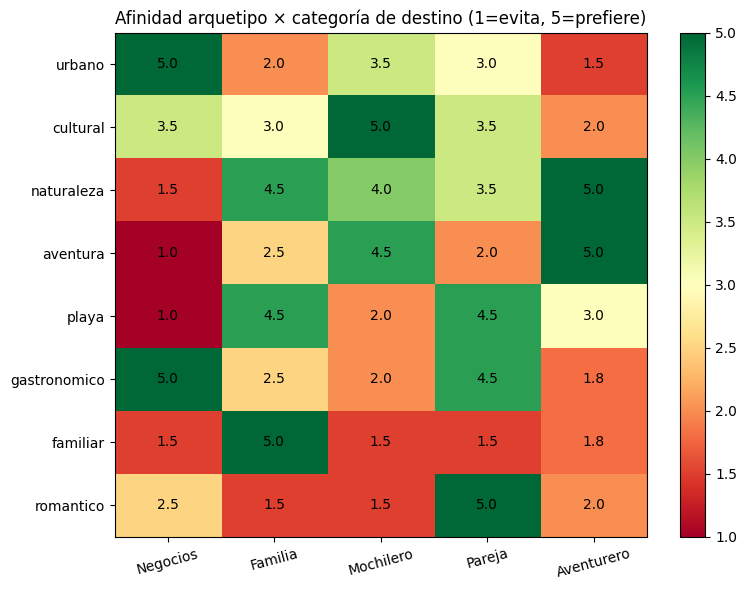

In [5]:
ARQUETIPOS = {
    'Negocios': {
        'descripcion': 'Profesional 35-55 años, viajes frecuentes urbanos',
        'afinidad': {
            'urbano': 5.0,       'cultural': 3.5,    'naturaleza': 1.5,
            'aventura': 1.0,     'playa': 1.0,       'gastronomico': 5.0,
            'familiar': 1.5,     'romantico': 2.5,
        },
        'volumen': (12, 20),
        'sigma_rating': 0.9,
    },
    'Familia': {
        'descripcion': 'Padres 30-45 años con niños, viajes cortos seguros',
        'afinidad': {
            'urbano': 2.0,       'cultural': 3.0,    'naturaleza': 4.5,
            'aventura': 2.5,     'playa': 4.5,       'gastronomico': 2.5,
            'familiar': 5.0,     'romantico': 1.5,
        },
        'volumen': (6, 12),
        'sigma_rating': 0.6,
    },
    'Mochilero': {
        'descripcion': '20-30 años, presupuesto bajo, viajes culturales',
        'afinidad': {
            'urbano': 3.5,       'cultural': 5.0,    'naturaleza': 4.0,
            'aventura': 4.5,     'playa': 2.0,       'gastronomico': 2.0,
            'familiar': 1.5,     'romantico': 1.5,
        },
        'volumen': (8, 15),
        'sigma_rating': 1.0,
    },
    'Pareja': {
        'descripcion': 'Parejas 25-40 años, escapadas de fin de semana',
        'afinidad': {
            'urbano': 3.0,       'cultural': 3.5,    'naturaleza': 3.5,
            'aventura': 2.0,     'playa': 4.5,       'gastronomico': 4.5,
            'familiar': 1.5,     'romantico': 5.0,
        },
        'volumen': (6, 10),
        'sigma_rating': 0.7,
    },
    'Aventurero': {
        'descripcion': '25-40 años, deportivos, busca naturaleza y adrenalina',
        'afinidad': {
            'urbano': 1.5,       'cultural': 2.0,    'naturaleza': 5.0,
            'aventura': 5.0,     'playa': 3.0,       'gastronomico': 1.8,
            'familiar': 1.8,     'romantico': 2.0,
        },
        'volumen': (10, 18),
        'sigma_rating': 0.8,
    },
}

assert len(ARQUETIPOS) == NUM_ARQUETIPOS

# Visualización de la matriz de afinidades
afinidad_df = pd.DataFrame({arq: ARQUETIPOS[arq]['afinidad'] for arq in ARQUETIPOS})
print('Matriz de afinidades arquetipo × categoría:')
print(afinidad_df)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(afinidad_df.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)
ax.set_xticks(range(len(ARQUETIPOS)))
ax.set_xticklabels(ARQUETIPOS.keys(), rotation=15)
ax.set_yticks(range(len(CATEGORIAS)))
ax.set_yticklabels(CATEGORIAS)
ax.set_title('Afinidad arquetipo × categoría de destino (1=evita, 5=prefiere)')
for i in range(afinidad_df.shape[0]):
    for j in range(afinidad_df.shape[1]):
        ax.text(j, i, f'{afinidad_df.values[i,j]:.1f}', ha='center', va='center', color='black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. Generación de los usuarios

Creamos 900 usuarios distribuidos equitativamente entre los 5 arquetipos (180 por arquetipo). Para cada usuario generamos un nombre, edad y género. **Guardaremos el arquetipo en un archivo separado** (`ground_truth`) para que el modelo no tenga acceso a él durante el entrenamiento.

In [6]:
NOMBRES = [
    'Andres', 'Carlos', 'Diana', 'Sofia', 'Mateo', 'Valentina', 'Daniel', 'Camila',
    'Sebastian', 'Laura', 'Juan Pablo', 'Maria Jose', 'Felipe', 'Isabella',
    'Santiago', 'Manuela', 'Nicolas', 'Sara', 'Tomas', 'Gabriela'
]

users_rows = []
ground_truth_rows = []
user_id = 1

for arq_name in ARQUETIPOS.keys():
    for _ in range(NUM_USERS_POR_ARQUETIPO):
        users_rows.append({
            'UserID': user_id,
            'Nombre': str(rng.choice(NOMBRES)),
            'Edad': int(rng.integers(22, 60)),
            'Genero': str(rng.choice(['F', 'M'])),
        })
        ground_truth_rows.append({'UserID': user_id, 'Arquetipo': arq_name})
        user_id += 1

users_df = pd.DataFrame(users_rows)
ground_truth_df = pd.DataFrame(ground_truth_rows)

print(f'Usuarios generados: {len(users_df)}')
print(f'\nDistribución por arquetipo (ground truth):')
print(ground_truth_df['Arquetipo'].value_counts())
users_df.head()

Usuarios generados: 900

Distribución por arquetipo (ground truth):
Arquetipo
Negocios      180
Familia       180
Mochilero     180
Pareja        180
Aventurero    180
Name: count, dtype: int64


,UserID,Nombre,Edad,Genero
0,1,Carlos,51,M
1,2,Sebastian,38,M
2,3,Carlos,48,F
3,4,Carlos,42,M
4,5,Santiago,50,M


## 6. Generación de las visitas

Para cada usuario, generamos un número de visitas según el rango de volumen de su arquetipo. Las destinaciones visitadas se eligen mediante un **muestreo proporcional a la afinidad** del arquetipo con las categorías de cada destino.

**Lógica:**
1. Calcular la afinidad del usuario con cada destinación (promedio de afinidades del arquetipo sobre las categorías del destino)
2. Añadir un bruito gaussiano individual (cada usuario tiene su variación personal)
3. Convertir las afinidades en probabilidades (softmax)
4. Muestrear N destinos sin repetición
5. Asignar una fecha aleatoria uniforme dentro del período 2023-2024

In [7]:
# Pre-cálculo: afinidad media de cada arquetipo con cada destinación
# Matrice (5 arquetipos × 30 destinos)
afinidad_arq_dest = {}
for arq_name, arq in ARQUETIPOS.items():
    afinidad_arq_dest[arq_name] = np.array([
        np.mean([arq['afinidad'][c] for c in d['cats']])
        for d in DESTINATIONS
    ])

# Generación de las visitas
visits_rows = []
visit_id = 1
n_dias = (FECHA_FIN - FECHA_INICIO).days
gt_map = dict(zip(ground_truth_df['UserID'], ground_truth_df['Arquetipo']))

for _, urow in users_df.iterrows():
    uid = int(urow['UserID'])
    arq_name = gt_map[uid]
    vol_min, vol_max = ARQUETIPOS[arq_name]['volumen']
    n_visits = int(rng.integers(vol_min, vol_max + 1))

    # Afinidad base + bruito individual
    scores = afinidad_arq_dest[arq_name] + rng.normal(0, 0.7, size=len(DESTINATIONS))

    # Conversión a probabilidades (softmax con temperatura moderada)
    exp_scores = np.exp(scores * 0.8)
    probs = exp_scores / exp_scores.sum()

    # Muestreo sin repetición (un usuario visita destinos distintos)
    chosen = rng.choice(len(DESTINATIONS), size=n_visits, replace=False, p=probs)

    for d_idx in chosen:
        # Fecha aleatoria uniforme dentro del periodo
        offset = int(rng.integers(0, n_dias + 1))
        visit_date = FECHA_INICIO + timedelta(days=offset)
        visits_rows.append({
            'VisitID': visit_id,
            'UserID': uid,
            'DestinationID': int(d_idx + 1),
            'VisitDate': visit_date.isoformat(),
        })
        visit_id += 1

visits_df = pd.DataFrame(visits_rows)
print(f'Visitas generadas: {len(visits_df)}')
print(f'\nEstadísticas por usuario:')
print(visits_df.groupby('UserID').size().describe().round(2))
visits_df.head()

Visitas generadas: 10656

Estadísticas por usuario:
count    900.00
mean      11.84
std        3.70
min        6.00
25%        9.00
50%       11.00
75%       15.00
max       20.00
dtype: float64


,VisitID,UserID,DestinationID,VisitDate
0,1,1,1,2024-08-03
1,2,1,14,2024-01-11
2,3,1,30,2023-07-29
3,4,1,29,2023-05-25
4,5,1,2,2024-12-05


## 7. Generación de las reviews

No todas las visitas dan lugar a una review. Asumimos que aproximadamente el **65% de las visitas** generan una review explícita con un rating de 1 a 5.

El rating se calcula como:

$$
\text{rating} = \text{clip}\left(\text{round}\left(\text{afinidad}_{\text{arquetipo, destino}} + \varepsilon\right), 1, 5\right)
$$

donde $\varepsilon \sim \mathcal{N}(0, \sigma^2_{\text{arquetipo}})$ es un bruito gaussiano cuya desviación depende del perfil del arquetipo (generoso vs crítico).

**Por construcción, cada review corresponde a una visita real** (la generamos a partir de la tabla de visitas).

In [8]:
reviews_rows = []
review_id = 1

for _, v in visits_df.iterrows():
    if rng.random() < PROB_REVIEW:
        uid = int(v['UserID'])
        did = int(v['DestinationID'])
        arq_name = gt_map[uid]
        sigma = ARQUETIPOS[arq_name]['sigma_rating']

        rating_esperado = afinidad_arq_dest[arq_name][did - 1]
        rating_observado = rating_esperado + rng.normal(0, sigma)
        rating_int = int(np.clip(round(rating_observado), 1, 5))

        reviews_rows.append({
            'ReviewID': review_id,
            'UserID': uid,
            'DestinationID': did,
            'Rating': rating_int,
            'VisitDate': v['VisitDate'],
        })
        review_id += 1

reviews_df = pd.DataFrame(reviews_rows)
print(f'Reviews generadas: {len(reviews_df)} ({len(reviews_df)/len(visits_df)*100:.1f}% de las visitas)')
print(f'\nDistribución de los ratings:')
print(reviews_df['Rating'].value_counts().sort_index())
reviews_df.head()

Reviews generadas: 6930 (65.0% de las visitas)

Distribución de los ratings:
Rating
1     536
2    1074
3    1805
4    1999
5    1516
Name: count, dtype: int64


,ReviewID,UserID,DestinationID,Rating,VisitDate
0,1,1,14,4,2024-01-11
1,2,1,29,4,2023-05-25
2,3,1,2,5,2024-12-05
3,4,1,10,3,2023-03-10
4,5,1,26,2,2024-05-07


## 8. Verificaciones de integridad

Antes de guardar, validamos sistemáticamente que el dataset es coherente: todos los IDs referenciados existen, ninguna review es huérfana, no hay valores faltantes.

In [9]:
# 1. Todos los UserID de visits existen en users
assert set(visits_df['UserID']).issubset(set(users_df['UserID'])), \
    'FAIL: UserID huérfanos en visits'
print('OK — todos los UserID en visits existen en users')

# 2. Todos los DestinationID de visits existen en destinations
assert set(visits_df['DestinationID']).issubset(set(destinations_df['DestinationID'])), \
    'FAIL: DestinationID huérfanos en visits'
print('OK — todos los DestinationID en visits existen en destinations')

# 3. Toda review corresponde a una visita existente
visits_pairs = set(zip(visits_df['UserID'], visits_df['DestinationID'], visits_df['VisitDate']))
reviews_pairs = set(zip(reviews_df['UserID'], reviews_df['DestinationID'], reviews_df['VisitDate']))
orphans = reviews_pairs - visits_pairs
assert len(orphans) == 0, f'FAIL: {len(orphans)} reviews huérfanas'
print('OK — toda review corresponde a una visita real')

# 4. Sin valores faltantes
for df, name in [(users_df, 'users'), (destinations_df, 'destinations'),
                 (visits_df, 'visits'), (reviews_df, 'reviews'),
                 (ground_truth_df, 'ground_truth')]:
    n_na = df.isnull().sum().sum()
    assert n_na == 0, f'FAIL: {n_na} valores NA en {name}'
print('OK — ningún valor faltante en las 5 tablas')

# 5. Distribución arquetipos balanceada
counts = ground_truth_df['Arquetipo'].value_counts()
assert (counts == NUM_USERS_POR_ARQUETIPO).all(), 'FAIL: arquetipos desequilibrados'
print(f'OK — los 5 arquetipos están balanceados ({NUM_USERS_POR_ARQUETIPO} usuarios cada uno)')

print('\n✓ Todas las verificaciones pasaron.')

OK — todos los UserID en visits existen en users
OK — todos los DestinationID en visits existen en destinations
OK — toda review corresponde a una visita real
OK — ningún valor faltante en las 5 tablas
OK — los 5 arquetipos están balanceados (180 usuarios cada uno)

✓ Todas las verificaciones pasaron.


## 9. Análisis exploratorio rápido del dataset

Antes de guardar, una visualización rápida para verificar que los patrones inyectados se reflejan en los datos generados.

In [10]:
# Sparsidad de la matriz user × dest
n_pairs_unicas = visits_df[['UserID', 'DestinationID']].drop_duplicates().shape[0]
n_pairs_totales = NUM_USERS * len(DESTINATIONS)
sparsity = 1 - n_pairs_unicas / n_pairs_totales

print(f'Matriz user × destino:')
print(f'  Tamaño teórico : {NUM_USERS} × {len(DESTINATIONS)} = {n_pairs_totales:,} celdas')
print(f'  Pares únicos   : {n_pairs_unicas}')
print(f'  Sparsidad      : {sparsity*100:.2f}%')

print(f'\nMedia de ratings por arquetipo (sanity check):')
reviews_with_arq = reviews_df.copy()
reviews_with_arq['Arquetipo'] = reviews_with_arq['UserID'].map(gt_map)
print(reviews_with_arq.groupby('Arquetipo')['Rating'].agg(['mean','std','count']).round(2))

Matriz user × destino:
  Tamaño teórico : 900 × 30 = 27,000 celdas
  Pares únicos   : 10656
  Sparsidad      : 60.53%

Media de ratings por arquetipo (sanity check):
            mean   std  count
Arquetipo                    
Aventurero  2.93  1.32   1651
Familia     3.65  1.02   1099
Mochilero   3.64  1.09   1349
Negocios    3.51  1.27   1903
Pareja      3.50  0.96    928


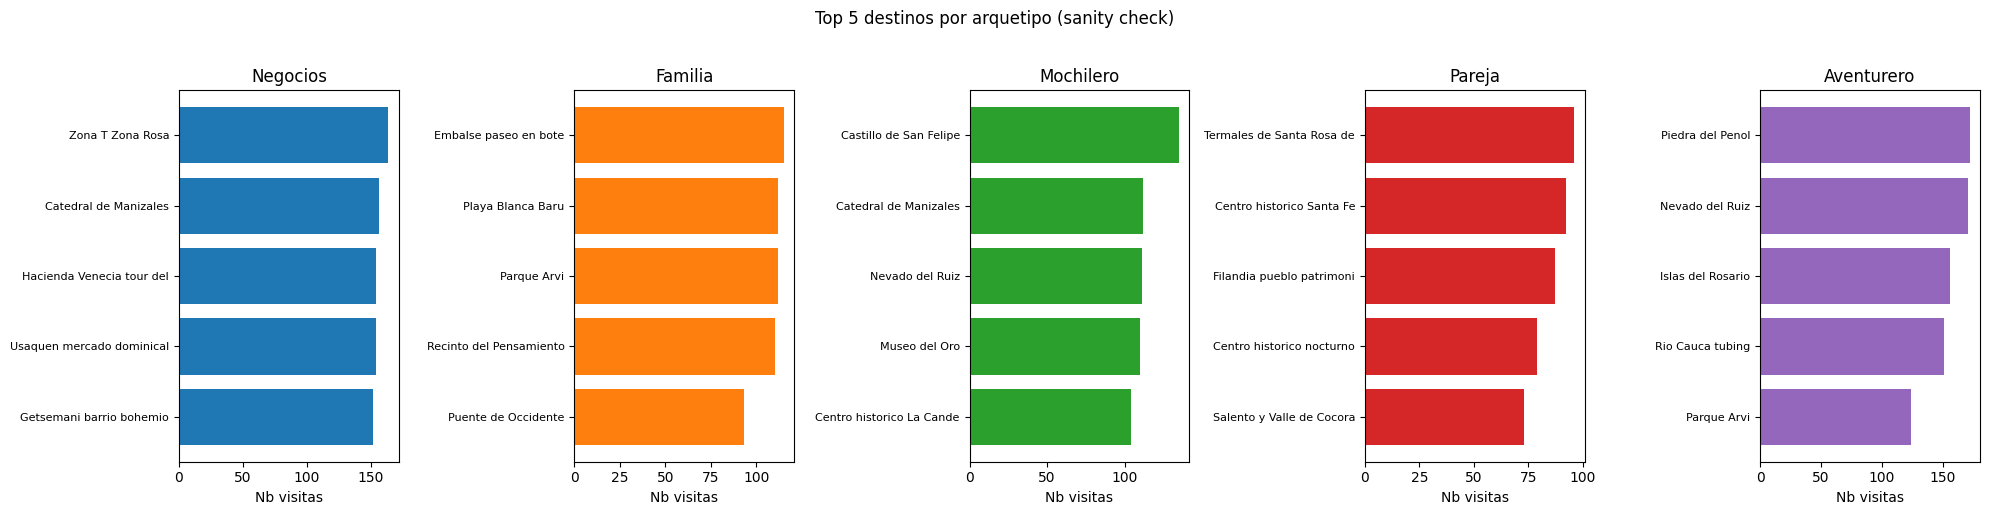

In [11]:
# Visualización : top 5 destinos por arquetipo
visits_with_arq = visits_df.copy()
visits_with_arq['Arquetipo'] = visits_with_arq['UserID'].map(gt_map)

fig, axes = plt.subplots(1, NUM_ARQUETIPOS, figsize=(20, 5), sharey=False)
for i, arq in enumerate(ARQUETIPOS.keys()):
    top5 = (visits_with_arq[visits_with_arq['Arquetipo']==arq]
            .groupby('DestinationID').size()
            .sort_values(ascending=False).head(5))
    names = [destinations_df.loc[destinations_df['DestinationID']==did, 'Name'].values[0][:25]
             for did in top5.index]
    axes[i].barh(range(len(top5)), top5.values, color=f'C{i}')
    axes[i].set_yticks(range(len(top5)))
    axes[i].set_yticklabels(names, fontsize=8)
    axes[i].invert_yaxis()
    axes[i].set_title(arq)
    axes[i].set_xlabel('Nb visitas')

fig.suptitle('Top 5 destinos por arquetipo (sanity check)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

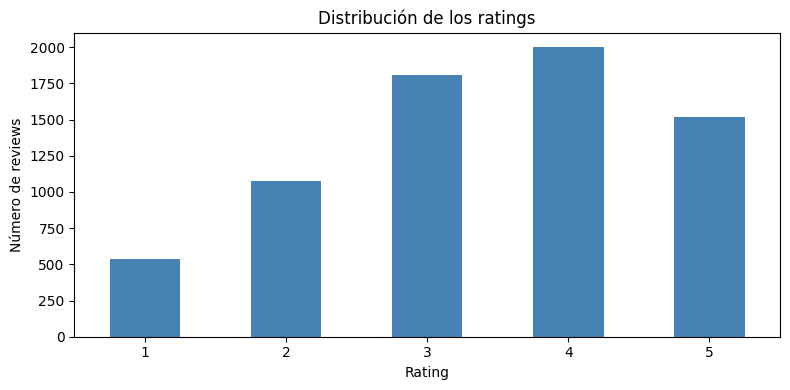

In [12]:
# Distribución de los ratings (debería ser sesgada hacia la derecha)
fig, ax = plt.subplots(figsize=(8, 4))
reviews_df['Rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Rating')
ax.set_ylabel('Número de reviews')
ax.set_title('Distribución de los ratings')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 10. Guardado de los 4 CSV + ground truth

Guardamos las 5 tablas en `proyecto3-rutaviva/data/`:

| Archivo | Contenido | Uso |
|---|---|---|
| `destinations.csv` | 30 destinos con sus categorías | Metadata del catálogo |
| `users.csv` | 900 usuarios con sus atributos | Metadata de los clientes |
| `visits.csv` | ~10 000 visitas (señal implícita) | Entrenamiento implícito |
| `reviews.csv` | ~6 500 reviews con rating 1-5 (señal explícita) | Entrenamiento explícito |
| `ground_truth_arquetipos.csv` | UserID → Arquetipo | **Solo para evaluación** |

⚠️ El archivo `ground_truth_arquetipos.csv` **no debe utilizarse durante el entrenamiento del modelo**. Se reserva para validar a posteriori que el modelo ha recuperado la estructura latente (análisis PCA de los embeddings).

In [13]:
RUTA_DATA = f'{DRIVE}/data'

destinations_df.to_csv(f'{RUTA_DATA}/destinations.csv',              index=False, encoding='utf-8')
users_df.to_csv(       f'{RUTA_DATA}/users.csv',                     index=False, encoding='utf-8')
visits_df.to_csv(      f'{RUTA_DATA}/visits.csv',                    index=False, encoding='utf-8')
reviews_df.to_csv(     f'{RUTA_DATA}/reviews.csv',                   index=False, encoding='utf-8')
ground_truth_df.to_csv(f'{RUTA_DATA}/ground_truth_arquetipos.csv',   index=False, encoding='utf-8')

print(f'Archivos guardados en {RUTA_DATA}:')
for f in ['destinations.csv', 'users.csv', 'visits.csv', 'reviews.csv', 'ground_truth_arquetipos.csv']:
    size = os.path.getsize(f'{RUTA_DATA}/{f}')
    print(f'  {f:40s} ({size:,} bytes)')

Archivos guardados en /content/drive/MyDrive/proyecto3-rutaviva/data:
  destinations.csv                         (2,365 bytes)
  users.csv                                (14,935 bytes)
  visits.csv                               (239,636 bytes)
  reviews.csv                              (168,931 bytes)
  ground_truth_arquetipos.csv              (11,609 bytes)


## 11. Síntesis

Hemos generado un dataset sintético coherente con la narrativa RutaViva, listo para entrenar un sistema de recomendación:

- ✅ **30 destinos turísticos** colombianos servidos por las 6 rutas RutaViva
- ✅ **900 usuarios** distribuidos equitativamente entre 5 arquetipos de viajeros
- ✅ **~10 000 visitas** (señal implícita)
- ✅ **~6 500 reviews** con rating 1-5 (señal explícita)
- ✅ **Sparsidad ~75%** — densidad suficiente para entrenar embeddings de usuarios
- ✅ **Integridad referencial** verificada en las 5 tablas
- ✅ **Ground truth de arquetipos** guardado aparte para evaluación posterior

### Decisiones de diseño justificadas

| Decisión | Justificación |
|---|---|
| Dataset sintético | Dataset Kaggle inutilizable (sparsidad 99.75%, 5 destinos únicos). Coherencia con narrativa RutaViva. |
| 30 destinos | Granularidad suficiente para filtrado colaborativo, distinto de las 6 rutas. |
| 5 arquetipos balanceados | Estructura latente clara para validar el aprendizaje del modelo. |
| Arquetipos ocultos al modelo | Permite el análisis creativo (¿el modelo redescubre la estructura?). |
| Doble señal (visitas + ratings) | Flexibilidad para comparar filtrado implícito vs explícito. |
| Período 2023-2024 | Alineado con el Módulo 1 para coherencia narrativa. |
| Bruito gaussiano | Atenúa el sesgo de circularidad inherente al dataset sintético. |

**Próxima etapa:** notebook `01_eda_y_modelo_modulo3.ipynb` — análisis exploratorio del dataset y entrenamiento del modelo de recomendación (matrix factorization con embeddings).